In [ ]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

from numpy.typing import NDArray
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy.optimize import curve_fit
from pybaselines import Baseline
import scienceplots
import damnit

from analysis.utils import (
    RHO_WATER_25C,
    deff_sq_to_volume,
    droplet_composition,
    fit_D2_law,
    gauss,
    get_train_timestamps,
    log_interpolate,
    piecewise_D2,
    read_intensity,
    read_volume,
    read_volume_series,
    style_plot,
)

plt.style.use('science')

In [2]:
db = damnit.Damnit(10400)

In [3]:
run_nr = 425
bg_run_nr = 464
bg_run_nr_waxs = 55

In [5]:
bg_waxs = read_intensity(bg_run_nr_waxs, db, variable="jungfrau_waxs_jf1")
avg_bg = bg_waxs.mean(["trainId", "cellId"])
q, iq_bg_waxs = avg_bg.q.values, avg_bg.data

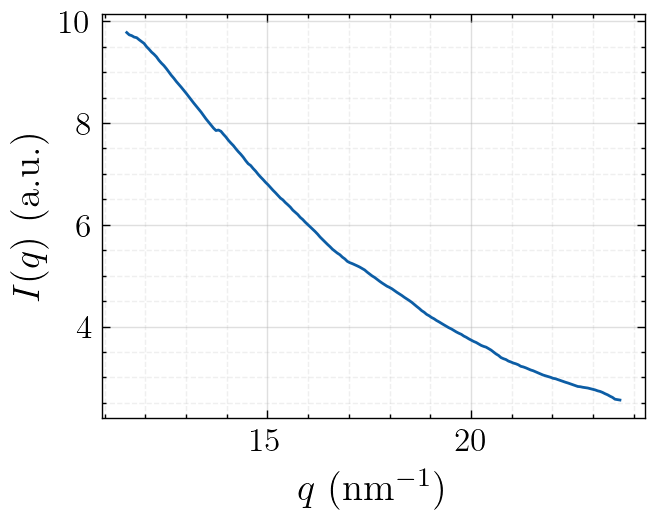

In [6]:
fig, ax = plt.subplots()
ax.plot(q, iq_bg_waxs)
style_plot(ax)
plt.show()

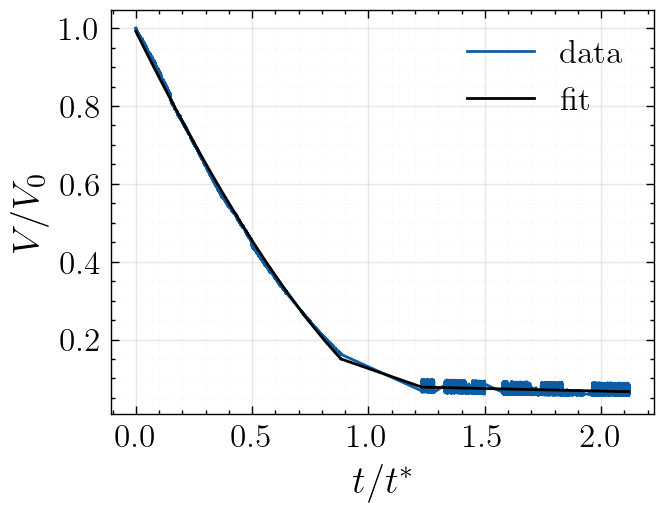

In [41]:
run_range = list(range(338, 370))
try:
    if run_range[0] == 443:
        run_range.remove(447)
    elif run_range[0] == 338:
        [run_range.remove(i) for i in [349, 353, 354, 355, 356]]
except:
    pass

v = read_volume_series(run_range, db)
timedelta = (v.time - v.isel(trainId=0).time).astype(float)*1e-9
popt, pcov = fit_D2_law(timedelta, v/v[0], t_star_guess=timedelta[len(timedelta)//2])
t_star = popt[-1]
v_fit = deff_sq_to_volume(piecewise_D2(timedelta, *popt))

fig, ax = plt.subplots()
ax.plot(timedelta / popt[-1], v/v[0], label="data")
ax.plot(timedelta / popt[-1], v_fit, label="fit", color='k')





style_plot(ax, xlabel="$t/t^*$", ylabel="$V/V_0$")
plt.show()

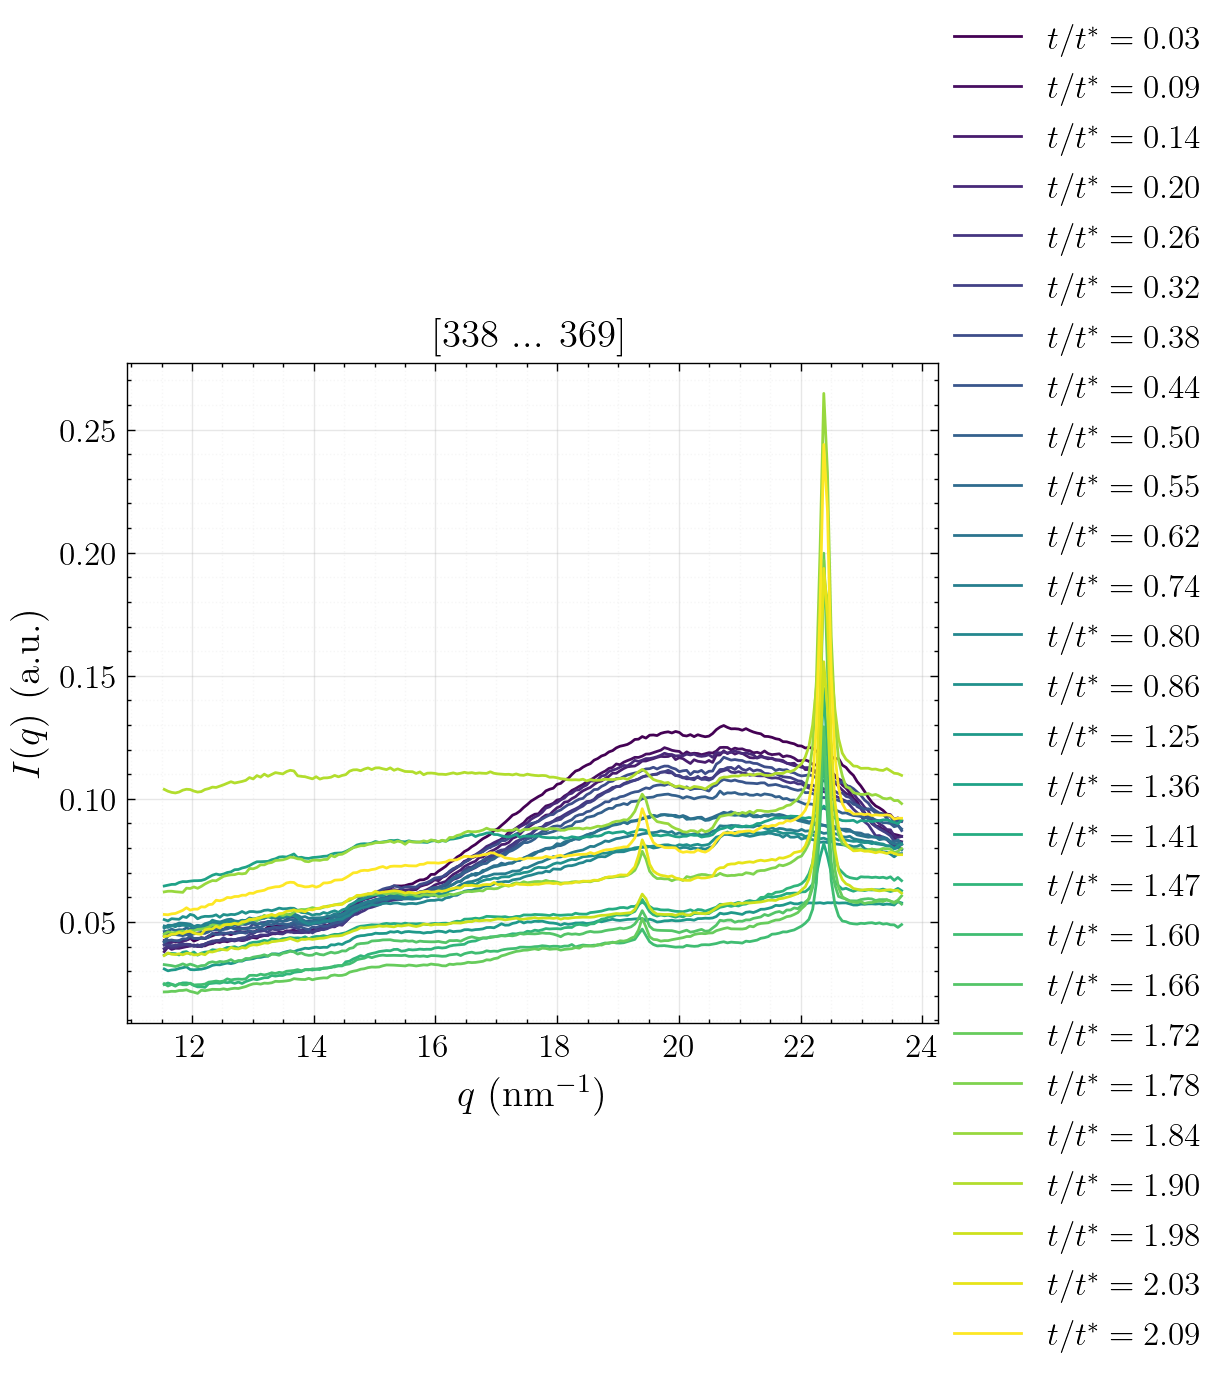

In [47]:
colors = plt.cm.viridis(np.linspace(0, 1, len(run_range)))

water_ring = (q>8)&(q<24)

peak_pos = []
peak_intens = []
rel_time = []

t0 = get_train_timestamps(run_range[0], db)[0]

fig, ax = plt.subplots(figsize=(3*2, 2*2))
for idx, run_nr in enumerate(run_range):
    waxs = read_intensity(run_nr, db, variable="jungfrau_waxs_jf1")
    ts = get_train_timestamps(run_nr, db)
    timedelta = ((ts - t0).astype(float)*1e-9).mean()
    waxs = waxs.where(waxs.data > 0).dropna("trainId")
    v = read_volume(run_nr, db).data
    wf = droplet_composition(v, v[0]).water_mass_fraction.mean()
    pulse_avg = waxs.mean("cellId")
    avg = pulse_avg.isel(trainId=np.s_[::10]).mean("trainId")
    q, iq = avg.q.values, avg.data
    # iq = gaussian_filter1d(iq, 3)
    # trains.append(pulse_avg.isel(trainId=tr_idx).trainId.values)
    iq_bg_sub = iq*(0.49*(1-wf)) - iq_bg_waxs*db[bg_run_nr_waxs]['total_transmission'].read().mean().data
    # iq_bg_sub = iq
    base = Baseline(q)
    bkg, params = base.arpls(iq_bg_sub, lam=1e2)
    x = q[water_ring]
    y = bkg[water_ring]
    popt, pcov = curve_fit(gauss, q[water_ring], bkg[water_ring], p0=[20, 1, 1], bounds=[[0, 0, -np.inf], [22, np.inf, np.inf]])
    peak_pos.append(popt[0])
    peak_intens.append(gauss(q[water_ring], *popt).max())
    rel_time.append(timedelta/t_star)
    # plt.plot(q[water_ring], bkg[water_ring]*v.mean(), color=colors[idx])
    ax.plot(q, iq_bg_sub, color=colors[idx], label=f"$t/t^*={timedelta/t_star:.2f}$")
    # plt.vlines(popt[0], ymin=0, ymax=1.5, color=colors[idx], lw=1.5)
    # plt.vlines(q[water_ring][np.argmax(bkg[water_ring])], ymin=0, ymax=1.5, color=colors[idx], lw=1.5)
    # plt.plot(q[water_ring], gauss(q[water_ring], *popt) * v.mean())
# plt.plot(q, iq_bg_waxs*0.2, "k")
# ax.plot(q, iq_bg_waxs/db[bg_run_nr_waxs]['total_transmission'].read().mean().data)
ax.set_title(f"[{run_range[0]} ... {run_range[-1]}]", fontsize=14)
fig.tight_layout()
style_plot(ax, fig_legend=True)
plt.savefig(f"r{run_range[0]}-{run_range[-1]}_waxs_all.png", dpi=300, bbox_inches="tight")
plt.show()

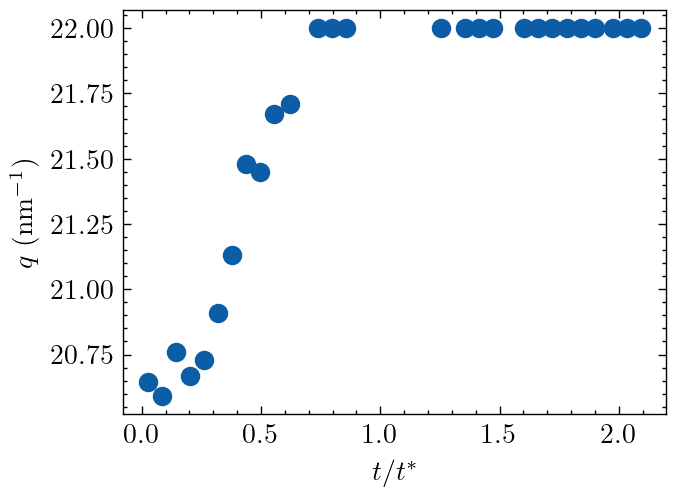

In [43]:
peak_pos = np.asarray(peak_pos)
x = list(range(423, 433))
# peak_pos = peak_pos[peak_pos>13]
plt.plot(rel_time, peak_pos, 'o')
plt.xlabel("$t/t^*$")
plt.ylabel(r"$q~$(nm$^{-1}$)")
plt.show()

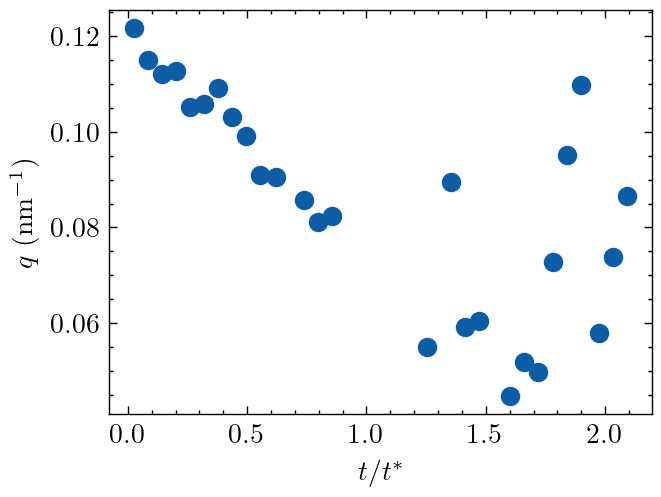

In [48]:
peak_intens = np.asarray(peak_intens)
# x = list(range(423, 433))
# peak_pos = peak_pos[peak_pos>13]
plt.plot(rel_time, peak_intens, 'o')
plt.xlabel("$t/t^*$")
plt.ylabel(r"$q~$(nm$^{-1}$)")
plt.show()

In [44]:
# Mass attenuation coefficients at 9.04 keV, cm^2/g.
MU_MASS_904: dict[str, float] = {
    "water": 6.785,
    "peg": 4.339,
    "protein": 4.548,
    "core": 142.8,  # FeOOH
}


def linear_attenuation(
    water_volume_fraction: NDArray[np.float64],
    ferritin_g_per_ml: NDArray[np.float64],
    peg_g_per_ml: NDArray[np.float64],
    protein_mass_fraction: float,
) -> NDArray[np.float64]:
    """mu in cm^-1 for the droplet interior."""
    return (
        MU_MASS_904["water"] * RHO_WATER_25C * water_volume_fraction
        + MU_MASS_904["peg"] * peg_g_per_ml
        + MU_MASS_904["protein"] * ferritin_g_per_ml * protein_mass_fraction
        + MU_MASS_904["core"] * ferritin_g_per_ml * (1.0 - protein_mass_fraction)
    )

In [45]:
bg_saxs = read_intensity(bg_run_nr, db, variable="agipd_saxs").isel(trainId=slice(0, 10))
v_bg_saxs = read_volume(bg_run_nr, db).data
comp = droplet_composition(v_bg_saxs, v_bg_saxs[0], ferritin_mg_per_ml_initial=0)
mu_bg = linear_attenuation(
    comp.water_volume_fraction,
    comp.ferritin_mg_per_ml * 1e-3,
    comp.peg_mg_per_ml * 1e-3,
    comp.ferritin.protein_mass_fraction,
)[0:10]
d_um = xr.open_dataset(db[bg_run_nr].file, group="droplet_fit").radius.sel(dim="x").data.mean()
t_bg = np.exp(-mu_bg * d_um*1e-3).mean()
medipt = bg_saxs.median(["q", "pulseId"])
medipt_filtered = medipt.where((medipt<medipt.quantile(0.95))&(medipt>medipt.quantile(0.05)), drop=True)
bg_saxs_filtered = bg_saxs.sel(trainId=medipt_filtered.trainId)
bg_saxs_filtered_avg = bg_saxs_filtered.mean(["trainId", "pulseId"])
iq_bg_saxs = bg_saxs_filtered_avg.data

In [46]:
timedelta

np.float64(2373.234984976706)

0.9239594845527536
0.7556537874831569


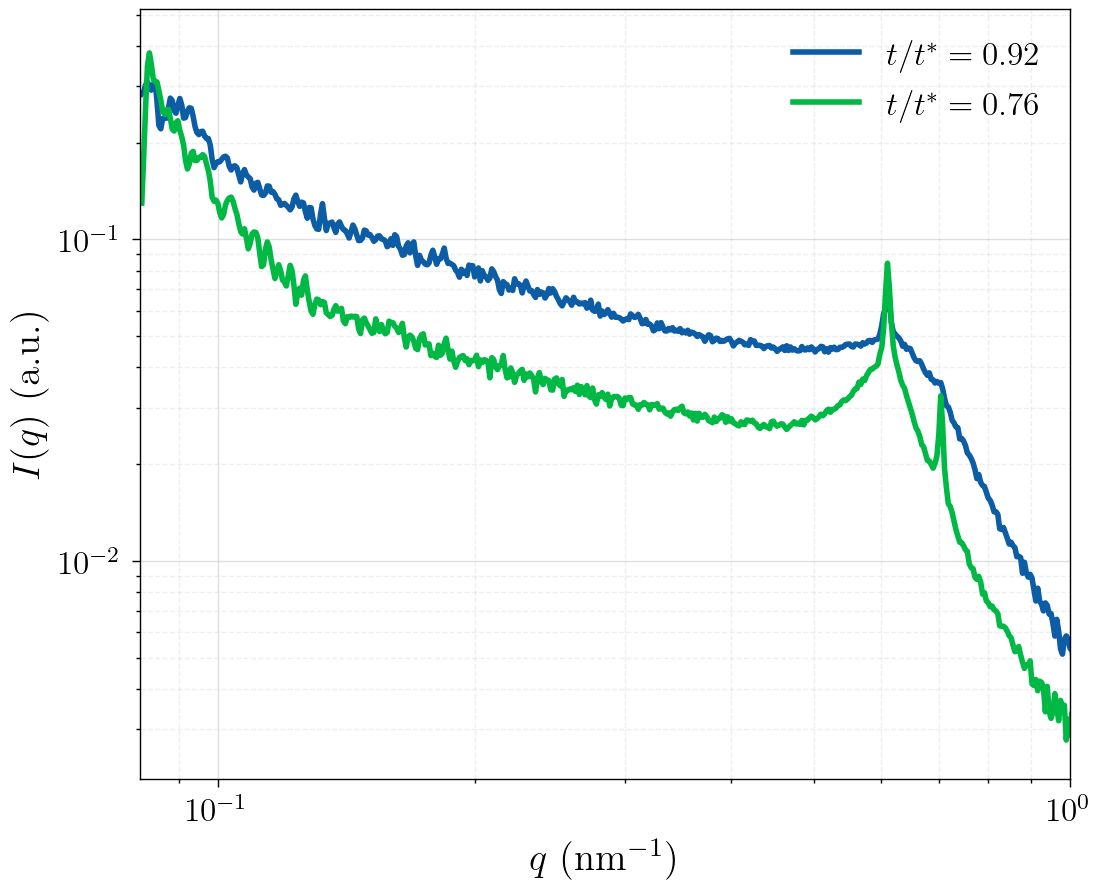

In [100]:
fig, ax = plt.subplots(figsize=(6, 5))

run_range = list(range(433, 443))

v = read_volume_series(run_range, db)
timedelta = (v.time - v.isel(trainId=0).time).astype(float)*1e-9
popt, pcov = fit_D2_law(timedelta, v/v[0], t_star_guess=timedelta[len(timedelta)//2])
t_star = popt[-1]

_run_nr = 435
saxs = read_intensity(_run_nr, db, variable="agipd_saxs").isel(trainId=0)
ts = get_train_timestamps(_run_nr, db)
t0 = get_train_timestamps(run_range[0], db)[0]
timedelta = ((ts - t0).astype(float)*1e-9).mean()
print(timedelta/t_star)
medipt = saxs.mean("q")
medipt_filtered = medipt.where((medipt<medipt.quantile(0.95))&(medipt>medipt.quantile(0.05)), drop=True)
saxs_filtered = saxs.sel(pulseId=medipt_filtered.pulseId)
saxs_avg = saxs_filtered.mean("pulseId")

v = read_volume(_run_nr, db).data
comp = droplet_composition(v, v[0], ferritin_mg_per_ml_initial=50)
mu_sample = linear_attenuation(
    comp.water_volume_fraction,
    comp.ferritin_mg_per_ml * 1e-3,
    comp.peg_mg_per_ml * 1e-3,
    comp.ferritin.protein_mass_fraction,
)[0:10]
d_um = xr.open_dataset(db[_run_nr].file, group="droplet_fit").radius.sel(dim="x").data.mean()
t_sample = np.exp(-mu_sample * d_um * 1e-3).mean()


q_log, iq_log = log_interpolate(saxs_avg.q.values, saxs_avg.data/(t_sample*i0_sample) - bg_saxs_filtered_avg.data/(t_bg*i0_bg))
ax.loglog(q_log, iq_log, lw=2, label=f"$t/t^*={timedelta/t_star:.2f}$")

# ----------------------------------------------------------------------------------------

run_range = list(range(443, 453))
try:
    run_range.remove(447)
except:
    pass

v = read_volume_series(run_range, db)
timedelta = (v.time - v.isel(trainId=0).time).astype(float)*1e-9
popt, pcov = fit_D2_law(timedelta, v/v[0], t_star_guess=timedelta[len(timedelta)//2])
t_star = popt[-1]

_run_nr = 445
saxs = read_intensity(_run_nr, db, variable="agipd_saxs").isel(trainId=0)
ts = get_train_timestamps(_run_nr, db)
t0 = get_train_timestamps(run_range[0], db)[0]
timedelta = ((ts - t0).astype(float)*1e-9).mean()
print(timedelta/t_star)
medipt = saxs.mean("q")
medipt_filtered = medipt.where((medipt<medipt.quantile(0.95))&(medipt>medipt.quantile(0.05)), drop=True)
saxs_filtered = saxs.sel(pulseId=medipt_filtered.pulseId)
saxs_avg = saxs_filtered.mean("pulseId")

v = read_volume(_run_nr, db).data
comp = droplet_composition(v, v[0], ferritin_mg_per_ml_initial=50)
mu_sample = linear_attenuation(
    comp.water_volume_fraction,
    comp.ferritin_mg_per_ml * 1e-3,
    comp.peg_mg_per_ml * 1e-3,
    comp.ferritin.protein_mass_fraction,
)[0:10]
d_um = xr.open_dataset(db[_run_nr].file, group="droplet_fit").radius.sel(dim="x").data.mean()
t_sample = np.exp(-mu_sample * d_um * 1e-3).mean()

q_log, iq_log = log_interpolate(saxs_avg.q.values, saxs_avg.data/(t_sample*i0_sample) - bg_saxs_filtered_avg.data/(t_bg*i0_bg))
ax.loglog(q_log, iq_log, lw=2, label=f"$t/t^*={timedelta/t_star:.2f}$")

ax.set_ylim(2.1e-3,)
ax.set_xlim(8.1e-2, 1)
# ax.spines[['right', 'top']].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.tick_params(which='both', direction='out')
ax.legend()
style_plot(ax)
plt.show()

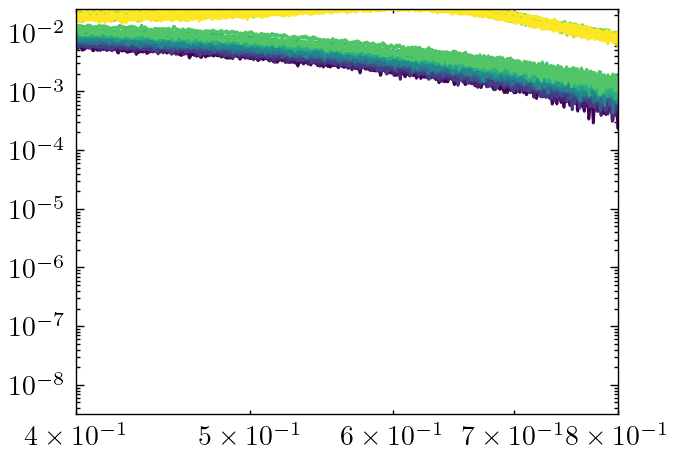

In [50]:
from scipy.signal import find_peaks

run_range = range(370, 382)
colors = plt.cm.viridis(np.linspace(0, 1, len(run_range)))

peaks_q = []
peaks_intensity = []


for idx, run_nr in enumerate(run_range):
    saxs = read_intensity(run_nr, db, variable="agipd_saxs")
    medipt = saxs.median(["q", "pulseId"])
    medipt_filtered = medipt.where((medipt<medipt.quantile(0.95))&(medipt>medipt.quantile(0.05)), drop=True)
    saxs_filtered = saxs.sel(trainId=medipt_filtered.trainId)
    for tr_idx in range(0, len(saxs_filtered.trainId), 100):
        avg = saxs_filtered.isel(trainId=tr_idx).isel(pulseId=np.s_[::10]).mean("pulseId")
        q, iq = avg.q.values, avg.data
        iq_bg_sub = iq - iq_bg_saxs*0.9
        q = q[iq_bg_sub>0]
        iq_bg_sub = iq_bg_sub[iq_bg_sub>0]
        base = Baseline(q)
        bkg, params = base.arpls(iq_bg_sub, lam=1e6)
        plt.loglog(q, iq_bg_sub, color=colors[idx])
        iq_flat = iq_bg_sub-bkg
        ferritin_peak_range = (q>0.4)&(q<0.8)
        peaks, _ = find_peaks(iq_flat[ferritin_peak_range], prominence=0.002)
        peaks_q.append(q[ferritin_peak_range][peaks])
        peaks_intensity.append(iq_flat[ferritin_peak_range][peaks])
        # plt.plot(q, iq_bg_sub-bkg, color=colors[idx])
    # plt.vlines(q[ferritin_peak_range][peaks], ymin=0, ymax=0.03)
# plt.loglog(q, iq_bg_saxs, 'k')
# plt.ylim(1e-3,)
# plt.xlim(0.4, 0.8)
# plt.ylim(-0.001, 0.025)
plt.show()

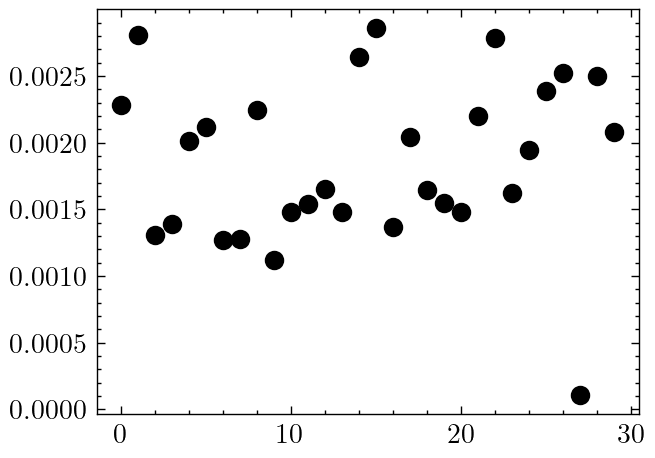

In [175]:
for idx, p in enumerate(peaks_intensity):
    if p.size > 0:
        plt.plot(idx, p[0], 'ok')
    else:
        plt.plot(idx, 0, 'ok')